# Régression du prix — français d'occasion (french-second-hand-cars)

Notebook **end-to-end** en deux temps :
1. **Régression linéaire simple** (`LinearRegression`) — repère de départ.
2. **ElasticNet** — régression « régularisée » qui combine Ridge (L2) et Lasso (L1), pour comparer.

**Rappel des métriques** (toutes = « à quel point on se trompe ») :
- **MAE** = erreur moyenne en euros (intuitive).
- **RMSE** = erreur en euros, mais **punit fort les gros ratés** (si RMSE ≫ MAE → quelques grosses erreurs).
- **R²** = part des variations de prix expliquée (0 = nul, 1 = parfait).

> On reste sur du **linéaire** (interprétable, aligné BC04). Code partagé dans `ml/src/features.py`, données brutes jamais modifiées.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from features import clean_cars, load_premium_table, add_brand_features

RAW = "../../data/french-second-hand-cars/raw/French_second_hand_cars.csv"
REF = "../../references/premium_brand.csv" 

## 🟦 1. PRÉPROCESSING — nettoyage + features

`clean_cars` retire les électriques purs, parse les colonnes sales et dérive
`boite_auto`, `garantie_constructeur`, `garantie_mois`. `add_brand_features`
extrait la marque (multi-mots gérés) et son `niveau` premium (0/1/2).

In [2]:
df = clean_cars(RAW)
ref = load_premium_table(REF)
df = add_brand_features(df, ref)

# sauvegarde du nettoyé (raw jamais modifié)
PROC = Path("../../data/french-second-hand-cars/processed")
PROC.mkdir(parents=True, exist_ok=True)
df.to_csv(PROC / "cars_clean.csv", index=False)

print("shape:", df.shape, "| marques non reconnues:", df["marque"].isna().sum())
df[["carmodel","marque","palier","niveau","boite_auto","garantie_constructeur","garantie_mois"]].head(3)

shape: (2340, 50) | marques non reconnues: 0


,carmodel,marque,palier,niveau,boite_auto,garantie_constructeur,garantie_mois
0,\n RENAULT TWINGO 3\n,RENAULT,generaliste,0,0,0,12.0
1,\n BMW SERIE 4 F36 GRAN COUPE\n,BMW,premium,1,1,0,24.0
2,\n BMW SERIE 2 F45 ACTIVE TOURER\n,BMW,premium,1,1,0,6.0


## 🟦 2. PRÉPROCESSING — features (X), cible (y), split train/test

- **X** = les features, **y** = le prix (cible).
- Split **80 % train / 20 % test**, `random_state=42` pour la reproductibilité.

In [3]:
features = ["annee", "kilometrage", "puissance_din", "puissance_fisc",
            "nombredeportes", "nombredeplaces",
            "niveau", "boite_auto", "garantie_constructeur", "garantie_mois"]

data = df[features + ["price"]].dropna(subset=["price"])   # on ne drop que la cible
X, y = data[features], data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (1872, 10) | test: (468, 10)


In [4]:
# petit utilitaire : nuage réel vs prédit (repère de lecture)
def plot_reel_vs_predit(y_true, y_pred, titre):
    plt.figure(figsize=(6.5, 6.5))
    plt.scatter(y_true, y_pred, alpha=0.4)
    lims = [y_true.min(), y_true.max()]
    plt.plot(lims, lims, "r--", label="prédiction parfaite")
    plt.xlabel("Prix réel (€)"); plt.ylabel("Prix prédit (€)")
    plt.title(titre); plt.legend(); plt.tight_layout(); plt.show()

# Temps 1 — Régression linéaire simple

Le modèle le plus direct : `LinearRegression`.
`garantie_mois` a des trous (NA) → on les **remplit par la médiane du train** (jamais du test → pas de fuite).

## 🟩 3. ENTRAÎNEMENT

In [5]:
med = X_train.median()
X_train_f = X_train.fillna(med)
X_test_f  = X_test.fillna(med)

lin = LinearRegression()
lin.fit(X_train_f, y_train)
print("modèle entraîné sur", len(X_train_f), "voitures")

modèle entraîné sur 1872 voitures


## 🟥 4. ÉVALUATION + graphique

MAE  : 8,742 €
RMSE : 15,813 €
R²   : 0.727


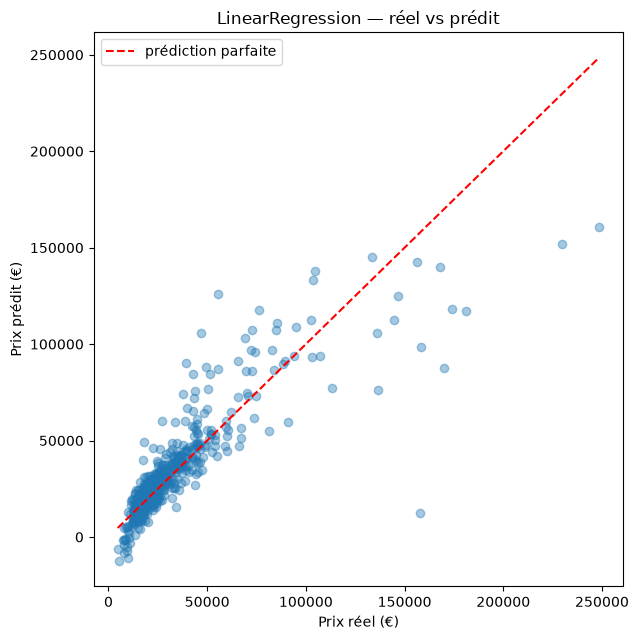

In [6]:
y_pred_lin = lin.predict(X_test_f)

mae_lin  = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin   = r2_score(y_test, y_pred_lin)
print(f"MAE  : {mae_lin:,.0f} €\nRMSE : {rmse_lin:,.0f} €\nR²   : {r2_lin:.3f}")

plot_reel_vs_predit(y_test, y_pred_lin, "LinearRegression — réel vs prédit")

# Temps 2 — ElasticNet (régularisation Ridge + Lasso)

**Le souci du linéaire simple** : ses coefficients peuvent s'emballer (features qui se
ressemblent, ex. puissance din / fiscale) → il colle trop au train (**overfitting**).

**ElasticNet** ajoute une **pénalité** qui bride les coefficients. Elle mélange deux effets :
- façon **Ridge** (L2) : réduit tous les coefficients ;
- façon **Lasso** (L1) : en met certains **à 0** (sélection de features).

Deux hyperparamètres, réglés par `GridSearchCV` (validation croisée) :
- **`alpha`** = force globale de la pénalité ;
- **`l1_ratio`** = dosage Lasso↔Ridge (0 = tout Ridge, 1 = tout Lasso).

Prérequis : **StandardScaler** (même échelle pour toutes les features), dans un **pipeline**
→ fit sur le train seul, pas de fuite.

## 🟩🟥 5. Entraînement + évaluation + graphique

meilleurs hyperparamètres: {'model__alpha': 1, 'model__l1_ratio': 0.5}
MAE  : 8,192 €
RMSE : 16,217 €
R²   : 0.713


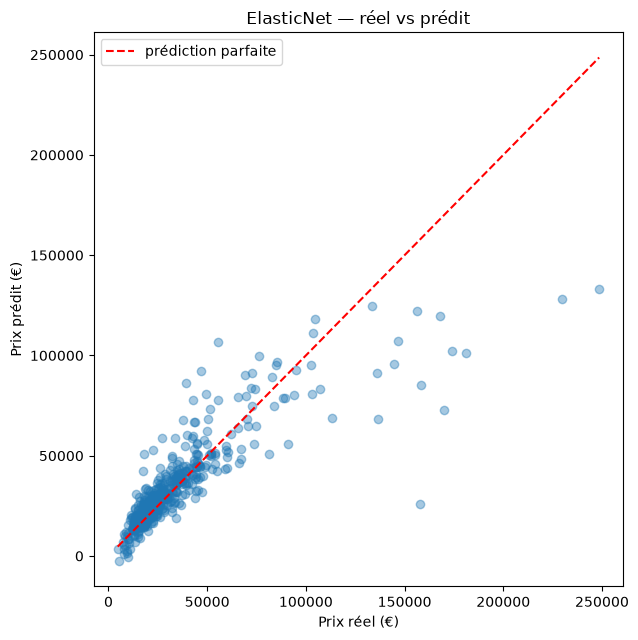

In [7]:
pipe = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(max_iter=10000))])
grille = {"model__alpha": [0.1, 1, 10, 100, 1000],
          "model__l1_ratio": [0.1, 0.5, 0.9]}

grid = GridSearchCV(pipe, grille, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train_f, y_train)
enet = grid.best_estimator_
print("meilleurs hyperparamètres:", grid.best_params_)

y_pred_enet = enet.predict(X_test_f)
mae_enet  = mean_absolute_error(y_test, y_pred_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
r2_enet   = r2_score(y_test, y_pred_enet)
print(f"MAE  : {mae_enet:,.0f} €\nRMSE : {rmse_enet:,.0f} €\nR²   : {r2_enet:.3f}")

plot_reel_vs_predit(y_test, y_pred_enet, "ElasticNet — réel vs prédit")

## 📊 6. Comparaison des deux modèles

In [8]:
comparaison = pd.DataFrame([
    {"modèle": "LinearRegression", "hyperparams": "—",
     "MAE (€)": round(mae_lin), "RMSE (€)": round(rmse_lin), "R²": round(r2_lin,3)},
    {"modèle": "ElasticNet", "hyperparams": grid.best_params_,
     "MAE (€)": round(mae_enet), "RMSE (€)": round(rmse_enet), "R²": round(r2_enet,3)},
])
comparaison

,modèle,hyperparams,MAE (€),RMSE (€),R²
0,LinearRegression,—,8742,15813,0.727
1,ElasticNet,"{'model__alpha': 1, 'model__l1_ratio': 0.5}",8192,16217,0.713


## 🟥 7. Coefficients — que retient chaque modèle ?

Sur features standardisées, un coefficient = effet en € d'**un écart-type** de la feature
(donc comparables). Regarde si **ElasticNet** met des features à 0 (sélection auto).

In [9]:
coefs = pd.DataFrame({
    "feature": features,
    "LinearRegression": lin.coef_ * X_train_f.std().values,  # ramené à l'échelle std pour comparer
    "ElasticNet": enet.named_steps["model"].coef_,
}).round(0).sort_values("ElasticNet", key=abs, ascending=False)
coefs

,feature,LinearRegression,ElasticNet
3,puissance_fisc,10694.0,7620.0
2,puissance_din,8801.0,7496.0
6,niveau,6624.0,5072.0
1,kilometrage,-4409.0,-3472.0
0,annee,5330.0,2911.0
7,boite_auto,531.0,2052.0
4,nombredeportes,-1466.0,-1598.0
8,garantie_constructeur,1038.0,1096.0
9,garantie_mois,224.0,768.0
5,nombredeplaces,226.0,-347.0


## 🟥 8. Les deux modèles côte à côte

Même échelle, même jeu de test → comparaison directe des deux nuages.

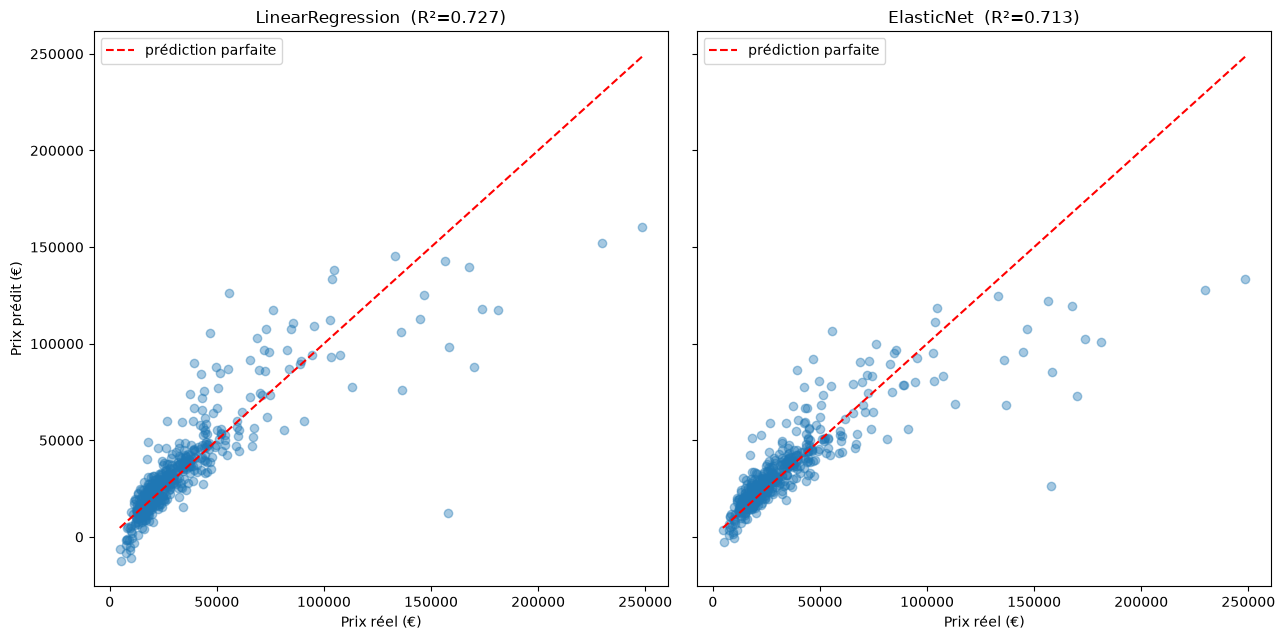

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)
lims = [y_test.min(), y_test.max()]
for a, pred, titre, r2 in [
    (ax[0], y_pred_lin,  "LinearRegression", r2_lin),
    (ax[1], y_pred_enet, "ElasticNet",       r2_enet),
]:
    a.scatter(y_test, pred, alpha=0.4)
    a.plot(lims, lims, "r--", label="prédiction parfaite")
    a.set_xlabel("Prix réel (€)")
    a.set_title(f"{titre}  (R²={r2:.3f})")
    a.legend()
ax[0].set_ylabel("Prix prédit (€)")
plt.tight_layout(); plt.show()

## Lecture

- **Temps 1 (LinearRegression)** = repère simple et lisible.
- **Temps 2 (ElasticNet)** : régularisation Ridge+Lasso, réglée pour minimiser le **MAE**.
  Elle stabilise les coefficients (compromis **biais↑ / variance↓**) et peut en annuler certains.
- Les deux graphiques montrent la même limite : nuage en cône, haut de gamme sous-estimé
  → le linéaire modélise mal la **dépréciation non linéaire** (piste future : modèle à arbres).
- Toujours pas de **fourchette + incertitude** (prochaine exigence produit).